# 🔍 Detección de Maras con YOLOv8
### Proyecto de Visión por Computador — Clasificación de 4 tipos de maras

**Integrantes:**
- Juan Diego Chaparro García
- Juan José Vargas
- Santiago Amado

## 1. Instalación de Dependencias
Instalación de las librerías necesarias: **Roboflow** para la descarga del dataset y **Ultralytics** para el uso del modelo YOLOv8.

In [1]:
# Instalar la librería de Roboflow para acceder y descargar datasets desde su plataforma
!pip install roboflow -q

# Instalar Ultralytics, el framework que contiene la implementación de YOLOv8
!pip install ultralytics -q

## 2. Importación de Librerías
Se importan todas las librerías necesarias para el manejo de archivos, descarga del dataset, entrenamiento del modelo y visualización de resultados.

In [2]:
import os                        # Manejo de rutas y sistema de archivos
from roboflow import Roboflow    # Acceso a datasets de Roboflow
from ultralytics import YOLO     # Modelo YOLOv8 para detección de objetos
import matplotlib.pyplot as plt  # Visualización de imágenes y gráficas
import pandas as pd              # Manejo de datos en formato tabular
import seaborn as sns            # Visualización estadística de datos
import random                    # Selección aleatoria de imágenes
import cv2                       # Procesamiento de imágenes con OpenCV

## 3. Conexión y Descarga del Dataset desde Roboflow
Se establece conexión con la API de Roboflow para acceder al proyecto de detección de maras y descargar el dataset en formato YOLOv8.

## Dataset

Link dataset: https://app.roboflow.com/juan-jose-vargas-correa-s-workspace/deteccion-maras-yb0z3/2

## Preprocessing

* Auto-Orient
* Resize

## Data Augmentation

* Outputs per training example
* Flip
* 90° Rotate
* Rotation
* Shear
* Hue
* Saturation
* Brightness
* Blur

In [ ]:
# IMPORTANTE: Roboflow requiere una clave API para autenticarse.
# Si usas Google Colab con Secrets, puedes obtenerla así:
# from google.colab import userdata
# api_key = userdata.get('ROBOFLOW_API_KEY')
api_key = ""  # Clave de acceso a la API de Roboflow

# Inicializar la conexión con Roboflow usando la clave API
rf = Roboflow(api_key=api_key)

# Acceder al workspace del proyecto de detección de maras
workspace = rf.workspace("juan-jose-vargas-correa-s-workspace")

# Seleccionar el proyecto específico de detección de maras
project = workspace.project("deteccion-maras-yb0z3")

# Descargar la versión 3 del dataset en formato YOLOv8
dataset = project.version(3).download("yolov8")

# Confirmar la conexión y la ubicación del dataset descargado
print(f"Conexión exitosa al proyecto de Roboflow: {project.name} (versión 2)")
print(f"Dataset descargado en: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...
Conexión exitosa al proyecto de Roboflow: Deteccion-Maras (versión 2)
Dataset descargado en: /content/Deteccion-Maras-3


## 4. Verificación de la Estructura del Dataset
Se visualiza la estructura de carpetas del dataset descargado para confirmar que contiene las particiones de entrenamiento, validación y prueba.

In [4]:
# Mostrar la estructura de directorios del dataset (hasta 2 niveles de profundidad)
# Esto permite verificar que las carpetas train/, valid/ y test/ existen correctamente
!tree -L 2 /content/Deteccion-Maras-3

/bin/bash: line 1: tree: command not found


## 5. Conteo de Imágenes por Partición
Se cuenta el número de imágenes disponibles en cada partición del dataset: entrenamiento, validación y prueba.

In [5]:
# Ruta raíz del dataset descargado
dataset_path = '/content/Deteccion-Maras-3'

# Construir las rutas a las carpetas de imágenes de cada partición
train_images_path = os.path.join(dataset_path, 'train', 'images')  # Imágenes de entrenamiento
valid_images_path = os.path.join(dataset_path, 'valid', 'images')  # Imágenes de validación
test_images_path  = os.path.join(dataset_path, 'test',  'images')  # Imágenes de prueba

# Contar el número de archivos en cada carpeta de imágenes
train_image_count = len(os.listdir(train_images_path))
valid_image_count = len(os.listdir(valid_images_path))
test_image_count  = len(os.listdir(test_images_path))

# Mostrar los resultados del conteo
print(f"Número de imágenes en el conjunto de entrenamiento (train): {train_image_count}")
print(f"Número de imágenes en el conjunto de validación  (valid):  {valid_image_count}")
print(f"Número de imágenes en el conjunto de prueba      (test):   {test_image_count}")

Número de imágenes en el conjunto de entrenamiento (train): 1698
Número de imágenes en el conjunto de validación  (valid):  163
Número de imágenes en el conjunto de prueba      (test):   81


## 6. Revisión del Archivo de Configuración del Dataset (`data.yaml`)
Se muestra el contenido del archivo `data.yaml`, el cual define las rutas del dataset y los nombres de las 4 clases de maras que el modelo debe detectar.

In [6]:
# Ruta al dataset (ya definida en la celda anterior)
dataset_path = '/content/Deteccion-Maras-3'

# Mostrar el contenido del archivo data.yaml
# Este archivo contiene: rutas a train/valid/test, número de clases (nc) y nombres de clases (names)
!cat {dataset_path}/data.yaml

names:
- black marble
- blue marble
- green marble
- white marble
nc: 4
roboflow:
  license: CC BY 4.0
  project: deteccion-maras-yb0z3
  url: https://universe.roboflow.com/juan-jose-vargas-correa-s-workspace/deteccion-maras-yb0z3/dataset/3
  version: 3
  workspace: juan-jose-vargas-correa-s-workspace
test: ../test/images
train: ../train/images
val: ../valid/images


## 7. Carga del Modelo YOLOv8s
Se carga el modelo preentrenado **YOLOv8s** (*small*). Este modelo fue seleccionado intencionalmente porque el proyecto será desplegado en una instancia **Amazon EC2**, donde los recursos de cómputo son limitados. La variante `s` (small) ofrece un buen equilibrio entre **precisión y eficiencia**, siendo lo suficientemente liviana para ejecutarse en producción sin requerir una GPU de alto rendimiento, a diferencia de las variantes más pesadas como `m`, `l` o `x`.

In [7]:
# Cargar el modelo YOLOv8s preentrenado con pesos de COCO
# Se elige la variante 'small' (s) por su bajo consumo de recursos,
# ideal para el despliegue en Amazon EC2 donde la capacidad de cómputo es limitada
model = YOLO('yolov8s.pt')

# Mostrar un resumen de la arquitectura del modelo cargado
print("Modelo YOLOv8s cargado exitosamente:")
print(model.info())

Modelo YOLOv8s cargado exitosamente:
YOLOv8s summary: 129 layers, 11,166,560 parameters, 0 gradients, 28.8 GFLOPs
(129, 11166560, 0, 28.816844800000002)


## 8. Entrenamiento del Modelo
Se entrena el modelo YOLOv8s con el dataset de maras. Se configura el número de épocas, el mecanismo de *early stopping*, el tamaño del lote y la resolución de las imágenes de entrada.

In [8]:
# Iniciar el proceso de entrenamiento del modelo con el dataset de maras
results = model.train(
    data=dataset_path + '/data.yaml',  # Ruta al archivo de configuración del dataset
    epochs=50,                         # Número máximo de épocas de entrenamiento
    patience=5,                        # Épocas sin mejora antes de detener el entrenamiento (early stopping)
    batch=16,                          # Número de imágenes procesadas por iteración
    imgsz=640                          # Tamaño de las imágenes de entrada (640x640 píxeles)
)

# Confirmar que el entrenamiento finalizó e indicar dónde se guardaron los resultados
print("Entrenamiento completado. Resultados guardados en: ", results.save_dir)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Deteccion-Maras-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

## 9. Carga del Mejor Modelo Entrenado
Una vez finalizado el entrenamiento, se carga el modelo con los mejores pesos obtenidos (`best.pt`), que corresponde a la época con mejor rendimiento en el conjunto de validación.

In [9]:
# Construir la ruta al archivo con los mejores pesos del modelo entrenado
# Ultralytics guarda automáticamente 'best.pt' en la carpeta weights/ del directorio de resultados
best_model_path = os.path.join(results.save_dir, 'weights', 'best.pt')

# Cargar el modelo YOLO con los mejores pesos obtenidos durante el entrenamiento
model_best = YOLO(best_model_path)

# Confirmar la carga exitosa del modelo
print(f"El mejor modelo entrenado ha sido cargado desde: {best_model_path}")

El mejor modelo entrenado ha sido cargado desde: /content/runs/detect/train/weights/best.pt


## 10. Validación del Modelo
Se evalúa el rendimiento del modelo sobre el conjunto de validación, calculando métricas clave como mAP50, mAP50-95, Precisión y Recall para los 4 tipos de maras.

In [10]:
# Ejecutar la validación del mejor modelo sobre el conjunto de datos de validación
# El método val() calcula automáticamente las métricas de detección de objetos
metrics = model_best.val(data=dataset_path + '/data.yaml')

# Mostrar las principales métricas de evaluación
print("Métricas de validación:")
print(f"mAP50-95: {metrics.box.map}")      # mAP promedio con umbrales IoU de 0.50 a 0.95
print(f"mAP50:    {metrics.box.map50}")     # mAP con umbral IoU de 0.50 (estándar PASCAL VOC)
print(f"Precisión: {metrics.box.mp:.4f}")   # Precisión media del modelo
print(f"Recall:    {metrics.box.mr:.4f}")   # Recall medio del modelo

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3061.9±823.1 MB/s, size: 168.2 KB)
val: Scanning /content/Deteccion-Maras-3/valid/labels.cache... 163 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 163/163 57.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 1.8it/s 6.1s
                   all        163        273       0.98       0.97      0.992      0.939
          black marble         52         66      0.983      0.955       0.99      0.946
           blue marble         59         79      0.994      0.975      0.995      0.982
          green marble         61         69      0.942      0.986      0.993      0.968
          white marble         48         59          1      0.965      0.989      0.861
Speed: 5.8ms preprocess, 10.2ms infe

## 11. Visualización de Métricas de Rendimiento
Se grafica un diagrama de barras comparativo con las métricas de evaluación del modelo para facilitar la interpretación visual de su desempeño en la detección de maras.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



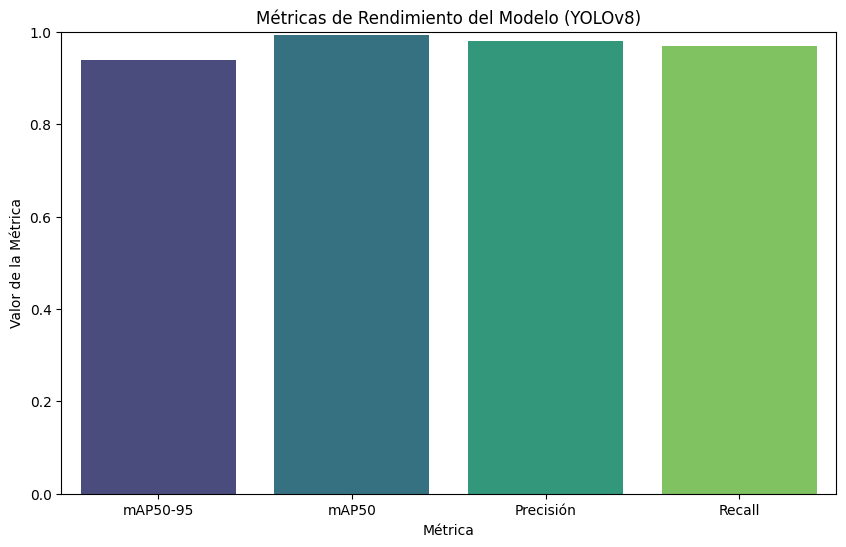

In [11]:
# Organizar las métricas de validación en un diccionario para su visualización
metrics_data = {
    'Métrica': ['mAP50-95', 'mAP50', 'Precisión', 'Recall'],  # Nombres de las métricas
    'Valor': [
        metrics.box.map,    # mAP promedio con múltiples umbrales IoU
        metrics.box.map50,  # mAP con umbral IoU = 0.50
        metrics.box.mp,     # Precisión media del modelo
        metrics.box.mr      # Recall medio del modelo
    ]
}

# Crear un DataFrame de pandas con las métricas para facilitar su manipulación
metrics_df = pd.DataFrame(metrics_data)

# Graficar las métricas en un diagrama de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='Métrica', y='Valor', data=metrics_df, palette='viridis')  # Paleta de color viridis
plt.ylim(0, 1)                                          # Las métricas van de 0 a 1
plt.title('Métricas de Rendimiento del Modelo (YOLOv8)')  # Título del gráfico
plt.ylabel('Valor de la Métrica')                        # Etiqueta del eje Y
plt.xlabel('Métrica')                                    # Etiqueta del eje X
plt.show()

## 12. Visualización de las Curvas de Entrenamiento
Se muestra el gráfico `results.png` generado por Ultralytics, el cual contiene las curvas de evolución de las métricas (Precisión, Recall, mAP) a lo largo de las épocas de entrenamiento.

Mostrando gráficos de métricas desde: /content/runs/detect/train/results.png


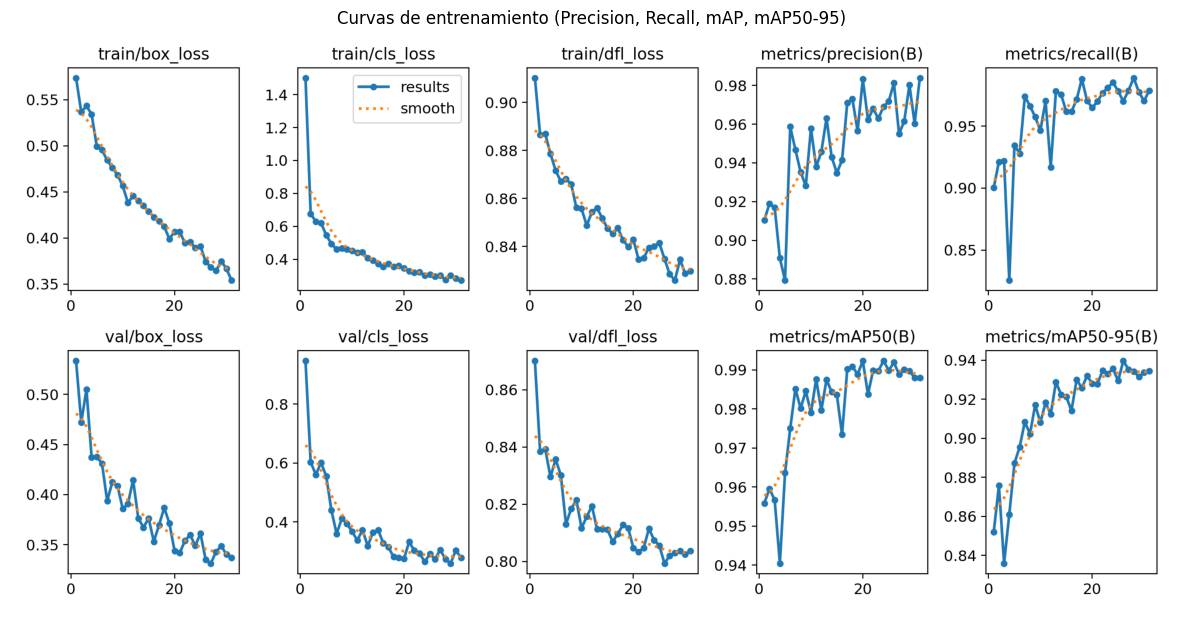

In [12]:
# Obtener el directorio donde se guardaron los resultados del entrenamiento
save_dir = results.save_dir

# Construir la ruta al archivo results.png generado automáticamente por Ultralytics
# Este archivo contiene las curvas de entrenamiento de todas las métricas por época
results_plot_path = os.path.join(save_dir, 'results.png')

# Verificar si el archivo existe antes de intentar mostrarlo
if os.path.exists(results_plot_path):
    print(f"Mostrando gráficos de métricas desde: {results_plot_path}")
    img = plt.imread(results_plot_path)           # Leer la imagen del archivo
    plt.figure(figsize=(15, 10))                  # Definir tamaño de la figura
    plt.imshow(img)                               # Mostrar la imagen
    plt.axis('off')                               # Ocultar los ejes
    plt.title('Curvas de entrenamiento (Precision, Recall, mAP, mAP50-95)')  # Título
    plt.show()
else:
    # Si no se encuentra el archivo, indicar el problema al usuario
    print(f"No se encontró el archivo de resultados en: {results_plot_path}")
    print("Por favor, verifica la ruta o si el entrenamiento generó el archivo.")

## 13. Predicción en una Imagen de Prueba Aleatoria
Se selecciona aleatoriamente una imagen del conjunto de prueba y se realiza una predicción con el mejor modelo entrenado para visualizar las detecciones de maras.

Realizando predicción en la imagen: /content/Deteccion-Maras-3/test/images/IMG_4657_jpg.rf.03b6189fc0a96247fff7b6432a723055.jpg

image 1/1 /content/Deteccion-Maras-3/test/images/IMG_4657_jpg.rf.03b6189fc0a96247fff7b6432a723055.jpg: 640x480 1 black marble, 1 green marble, 45.7ms
Speed: 2.4ms preprocess, 45.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict


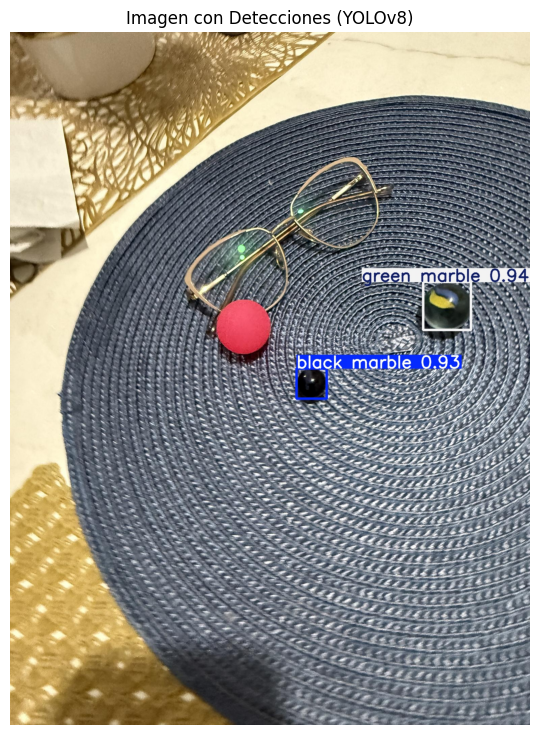

In [13]:
# Usar la ruta al directorio de imágenes de prueba (definida en celdas anteriores)
test_images_dir = test_images_path

# Obtener la lista de todas las imágenes en la carpeta de prueba
test_image_files = [f for f in os.listdir(test_images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

if not test_image_files:
    print("No se encontraron imágenes en la carpeta de prueba.")
else:
    # Seleccionar aleatoriamente una imagen del conjunto de prueba
    selected_image_name = random.choice(test_image_files)
    image_path = os.path.join(test_images_dir, selected_image_name)
    print(f"Realizando predicción en la imagen: {image_path}")

    # Ejecutar la predicción con el mejor modelo entrenado
    # conf=0.25: umbral mínimo de confianza para considerar una detección válida
    # save=True: guardar la imagen con las detecciones dibujadas
    # imgsz=640: tamaño de imagen de entrada al modelo
    results = model_best.predict(source=image_path, conf=0.25, save=True, imgsz=640)

    # Obtener el directorio donde se guardó la imagen con predicciones
    # Ultralytics guarda los resultados en 'runs/detect/predict' por defecto
    predict_dir = results[0].save_dir if results and hasattr(results[0], 'save_dir') else 'runs/detect/predict'

    # Verificar que el directorio de predicciones existe; si no, buscar el más reciente
    if not os.path.exists(predict_dir):
        all_predict_dirs = [d for d in os.listdir('runs/detect') if d.startswith('predict')]
        if all_predict_dirs:
            predict_dir = os.path.join('runs/detect', sorted(
                all_predict_dirs,
                key=lambda x: int(x.replace('predict', '') or 1),
                reverse=True
            )[0])

    # Construir la ruta completa a la imagen con las predicciones guardadas
    predicted_image_path = os.path.join(predict_dir, selected_image_name)

    # Mostrar la imagen con las detecciones si existe
    if os.path.exists(predicted_image_path):
        img_pred = plt.imread(predicted_image_path)  # Leer la imagen predicha
        plt.figure(figsize=(12, 9))
        plt.imshow(img_pred)                         # Mostrar la imagen
        plt.axis('off')                              # Ocultar los ejes
        plt.title('Imagen con Detecciones (YOLOv8)')  # Título de la figura
        plt.show()
    else:
        print(f"No se encontró la imagen predicha en: {predicted_image_path}")
        print("Por favor, revisa la configuración de 'save=True' y la ruta de salida.")

## 14. Predicción en Múltiples Imágenes de Prueba
Se realizan predicciones sobre todas las imágenes del conjunto de prueba y se visualizan hasta 5 resultados representativos con las detecciones de los 4 tipos de maras.

Realizando predicciones en 81 imágenes de prueba...

image 1/1 /content/Deteccion-Maras-3/test/images/IMG_7107_jpg.rf.649f87ed20ef4368be46f87609993bbf.jpg: 640x480 1 green marble, 13.5ms
Speed: 4.0ms preprocess, 13.5ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict

image 1/1 /content/Deteccion-Maras-3/test/images/IMG_6682_jpg.rf.3e8461292c0e8b46ec9a3046b522a422.jpg: 640x480 1 blue marble, 12.1ms
Speed: 4.0ms preprocess, 12.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict

image 1/1 /content/Deteccion-Maras-3/test/images/IMG_6661_jpg.rf.f222c62dc458d25a672a7eee36334655.jpg: 640x480 1 blue marble, 12.0ms
Speed: 2.4ms preprocess, 12.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict

image 1/1 /content/Deteccion-Maras-3/test/images/IMG_6595_jpg.rf.4afb37560abf1649804099ae1841eac1.jpg: 640x480 1 gr

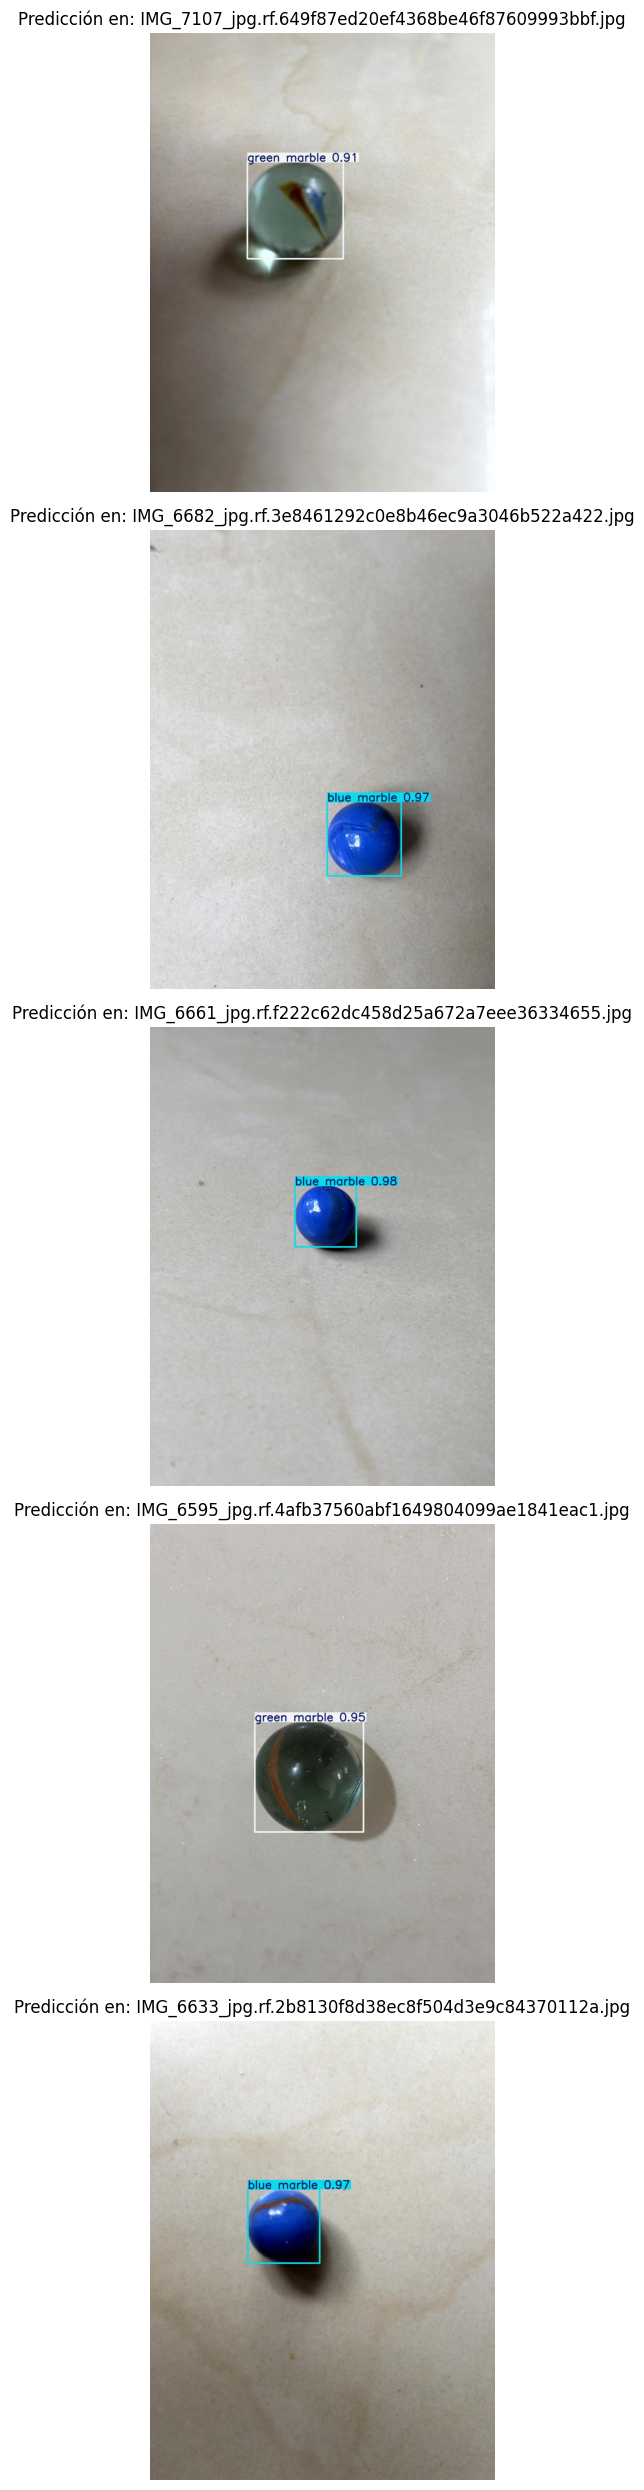

Todas las imágenes predichas se guardaron en subdirectorios dentro de 'runs/detect'.


In [14]:
# Usar la ruta al directorio de imágenes de prueba
test_images_dir = test_images_path

# Obtener la lista de imágenes en la carpeta de prueba (incluyendo extensión .JPG en mayúsculas)
test_image_files = [f for f in os.listdir(test_images_dir)
                    if f.endswith(('.jpg', '.jpeg', '.png', '.JPG'))]

if not test_image_files:
    print("No se encontraron imágenes en la carpeta de prueba.")
else:
    print(f"Realizando predicciones en {len(test_image_files)} imágenes de prueba...")

    predicted_images_paths = []  # Lista para almacenar rutas de imágenes predichas

    # Iterar sobre cada imagen del conjunto de prueba y realizar la predicción
    for i, image_name in enumerate(test_image_files):
        image_path = os.path.join(test_images_dir, image_name)

        # Predecir con el modelo; show=False evita abrir ventanas durante el bucle
        results = model_best.predict(source=image_path, conf=0.25, save=True, imgsz=640, show=False)

        # Guardar la ruta de cada imagen con sus detecciones
        if results and hasattr(results[0], 'save_dir'):
            predict_dir = results[0].save_dir
            predicted_image_path = os.path.join(predict_dir, image_name)
            if os.path.exists(predicted_image_path):
                predicted_images_paths.append(predicted_image_path)

        # Opcional: descomentar las líneas siguientes para limitar el procesamiento
        # if i >= 4:  # Procesar solo las primeras 5 imágenes
        #     break

    print(f"Se generaron {len(predicted_images_paths)} imágenes con predicciones.")

    # Mostrar un máximo de 5 imágenes predichas para no saturar la visualización
    num_images_to_show = min(len(predicted_images_paths), 5)
    if num_images_to_show > 0:
        print(f"Mostrando {num_images_to_show} ejemplos de predicciones:")
        plt.figure(figsize=(15, 5 * num_images_to_show))  # Ajustar el tamaño según las imágenes
        for i in range(num_images_to_show):
            img_pred = plt.imread(predicted_images_paths[i])  # Leer imagen predicha
            plt.subplot(num_images_to_show, 1, i + 1)         # Crear subgráfico
            plt.imshow(img_pred)                               # Mostrar imagen
            plt.axis('off')                                    # Ocultar ejes
            plt.title(f'Predicción en: {os.path.basename(predicted_images_paths[i])}')  # Nombre de archivo
        plt.tight_layout()  # Ajustar espaciado entre subgráficos
        plt.show()
    else:
        print("No se pudieron cargar imágenes predichas para mostrar.")

    print(f"Todas las imágenes predichas se guardaron en subdirectorios dentro de 'runs/detect'.")

## 15. Exportación del Modelo a Formato ONNX
Se exporta el mejor modelo entrenado al formato **ONNX** (*Open Neural Network Exchange*), un formato estándar e interoperable que permite desplegar el modelo en diferentes entornos de producción, incluyendo la instancia EC2.

In [15]:
# Definir la ruta de destino para el archivo exportado en formato ONNX
# Se guarda en la misma carpeta donde está el modelo best.pt
output_onnx_path = os.path.join(os.path.dirname(best_model_path), 'best_model.onnx')
print(f"Exportando el modelo a ONNX en: {output_onnx_path}")

# Exportar el modelo entrenado al formato ONNX
# opset=12: versión del operador ONNX a usar (compatible con la mayoría de frameworks de inferencia)
model_best.export(format='onnx', opset=12)

# Confirmar que la exportación fue exitosa
print("Modelo exportado a ONNX exitosamente.")

Exportando el modelo a ONNX en: /content/runs/detect/train/weights/best_model.onnx
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 8, 8400) (21.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 245ms
Prepared 4 packages in 9.04s
Installed 4 packages in 489ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.25.1
 + onnxslim==0.1.92

requirements: AutoUpdate success ✅ 10.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: s